# 04 — Train → Predict → Evaluate

## Goal
For each model: train on V2 features → predict test set → evaluate on validation set.
Step 6 combines LightGBM and XGBoost into a weighted average ensemble.

**This notebook is a pure orchestrator — all logic lives in `src/pipeline_evaluate.py`.**

## Per-model order (strict)
```
Train  →  Predict test (submission)  →  Evaluate (val metrics + plots)
```

## Inputs
```
outputs/preproc/X_train_lgbm.parquet   — label-encoded train features (LightGBM / XGBoost)
outputs/preproc/X_val_lgbm.parquet     — label-encoded val features   (LightGBM / XGBoost)
outputs/preproc/y_train.parquet        — training target
outputs/preproc/y_val.parquet          — validation target
outputs/preproc/encoding_map.pkl       — fitted label encoders
outputs/enriched/test_enriched.parquet — enriched test features
```

## Outputs
```
outputs/models/model_lgbm.pkl                  — trained LightGBM
outputs/models/model_xgb.pkl                   — trained XGBoost
outputs/submissions/submission_lgbm_v2.csv     — LightGBM submission
outputs/submissions/submission_xgb_v2.csv      — XGBoost submission
outputs/submissions/submission_ensemble_v2.csv — Ensemble submission
```

## V0 Baseline (reference)
```
ROC AUC : 0.9196
PR AUC  : 0.5804
```


# Step 1: Path Setup & Imports

In [1]:
import sys, os, pickle, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# Notebook lives in v2/ — go one level up to reach project root
PROJECT_ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
for subdir in ['', 'src', 'v0']:
    p = os.path.join(PROJECT_ROOT_PATH, subdir)
    if p not in sys.path:
        sys.path.insert(0, p)

from config import (
    PROJECT_ROOT, NON_FEATURE_COLS,
    ENRICHED_DIR, PREPROC_DIR, OUTPUTS_DIR
)
from pipeline_evaluate import (
    load_splits,
    train_lgbm_model,
    train_xgb_model,
)
from evaluate_ml import compute_metrics, plot_roc_pr, plot_feature_importance
from sklearn.metrics import roc_auc_score, average_precision_score

MODELS_DIR      = OUTPUTS_DIR / 'models'
SUBMISSIONS_DIR = OUTPUTS_DIR / 'submissions'

V0_ROC_AUC = 0.9196
V0_PR_AUC  = 0.5804

print(f'Project root    : {PROJECT_ROOT}')
print(f'Preproc dir     : {PREPROC_DIR}')
print(f'Models dir      : {MODELS_DIR}')
print(f'Submissions dir : {SUBMISSIONS_DIR}')

ModuleNotFoundError: No module named 'optuna.callbacks'

# Step 2: Execution Flags

- `RETRAIN_LGBM / RETRAIN_XGB`
  - `True`  → always retrain + save (overwrites existing model)
  - `False` → auto-check: if saved model exists → load; else → train + save

JSON params → auto-check: if `best_params_X.json` exists → use it; else → defaults

In [ ]:
# ── SET THESE FLAGS ─────────────────────────────────────────────────────────
# RETRAIN = True  → always retrain + save (overwrites existing model)
# RETRAIN = False → auto-check: if saved model exists → load; else → train + save
# JSON params     → auto-check: if best_params_X.json exists → use it; else → defaults

RETRAIN_LGBM = True
RETRAIN_XGB  = False
# ─────────────────────────────────────────────────────────────────────────────

PARAM_FILES = {
    'lgbm': OUTPUTS_DIR / 'best_params_lgbm.json',
    'xgb' : OUTPUTS_DIR / 'best_params_xgb.json',
}

MODEL_FILES = {
    'lgbm': MODELS_DIR / 'model_lgbm.pkl',
    'xgb' : MODELS_DIR / 'model_xgb.pkl',
}

print(f"  {'Model':<8} {'JSON':^14} {'Saved model':^14} {'Action'}")
print(f"  {'─'*58}")
_retrain_map = {'lgbm': RETRAIN_LGBM, 'xgb': RETRAIN_XGB}
for key in ['lgbm', 'xgb']:
    json_ok  = PARAM_FILES[key].exists()
    model_ok = MODEL_FILES[key].exists()
    retrain  = _retrain_map[key]
    if retrain:
        action = 'retrain (flag=True)'
    elif model_ok:
        action = 'load saved model'
    else:
        action = 'train (no saved model)'
    print(f"  {key:<8} {str(json_ok):^14} {str(model_ok):^14} {action}")


  Model         JSON       Saved model   Action
  ──────────────────────────────────────────────────────────
  lgbm          True           True      load saved model
  xgb           True           True      load saved model


# Step 3: Load Preprocessed Splits

In [ ]:
X_train_lgbm, X_val_lgbm, _, _, encoding_map, y_train, y_val = load_splits(PREPROC_DIR)


STEP 1 — Load preprocessed splits
   X_train_lgbm : (472432, 497)  (label-encoded, LightGBM / XGBoost)
   X_val_lgbm   : (118108, 497)    (label-encoded, LightGBM / XGBoost)
   X_train_raw  : (472432, 499)   (raw, for CatBoost)
   X_val_raw    : (118108, 499)     (raw, for CatBoost)
   encoding_map : 47 encoders
   y_train fraud rate : 3.5135%
   y_val   fraud rate : 3.4409%


# Step 4: LightGBM

## Step 4.1: Train LightGBM

In [ ]:
if RETRAIN_LGBM or not MODEL_FILES['lgbm'].exists():
    model_lgbm, y_pred_lgbm = train_lgbm_model(
        X_train_lgbm, y_train,
        X_val_lgbm,   y_val,
        models_dir  = MODELS_DIR,
        params_path = str(PARAM_FILES['lgbm']),
    )
else:
    with open(MODEL_FILES['lgbm'], 'rb') as f:
        model_lgbm = pickle.load(f)
    y_pred_lgbm = model_lgbm.predict_proba(X_val_lgbm)[:, 1].astype('float32')
    print(f'✅  Loaded model_lgbm ← {MODEL_FILES["lgbm"]}')

✅  Loaded model_lgbm ← C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_lgbm.pkl


## Step 4.2: Evaluate LightGBM

  Model               ROC AUC    PR AUC
  v0 baseline          0.9196    0.5804
  v2 LightGBM          0.9272    0.6039   Δ ROC=+0.0076  Δ PR=+0.0235


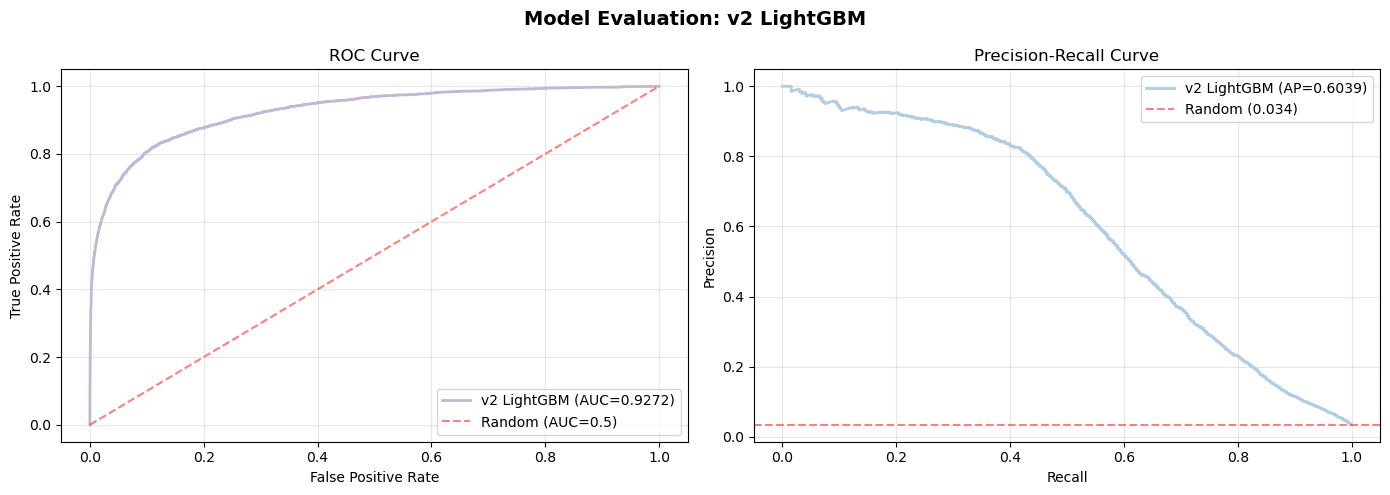

>> Top 30 features by importance:
     1. card1                           importance: 30229
     2. tx_day                          importance: 27740
     3. TransactionAmt                  importance: 25595
     4. card2                           importance: 23455
     5. addr1                           importance: 18566
     6. tx_dom                          importance: 18443
     7. tx_hour                         importance: 13469
     8. tx_amt_mean                     importance: 12031
     9. tx_amt_max                      importance: 11451
    10. hour_vs_typical                 importance: 11083
    11. tx_amt_std                      importance: 10919
    12. tx_amt_min                      importance: 10748
    13. P_emaildomain                   importance: 10725
    14. D15                             importance: 9772
    15. uid_time_entropy                importance: 9576
    16. delta_amt                       importance: 9257
    17. time_since_last_tx              i

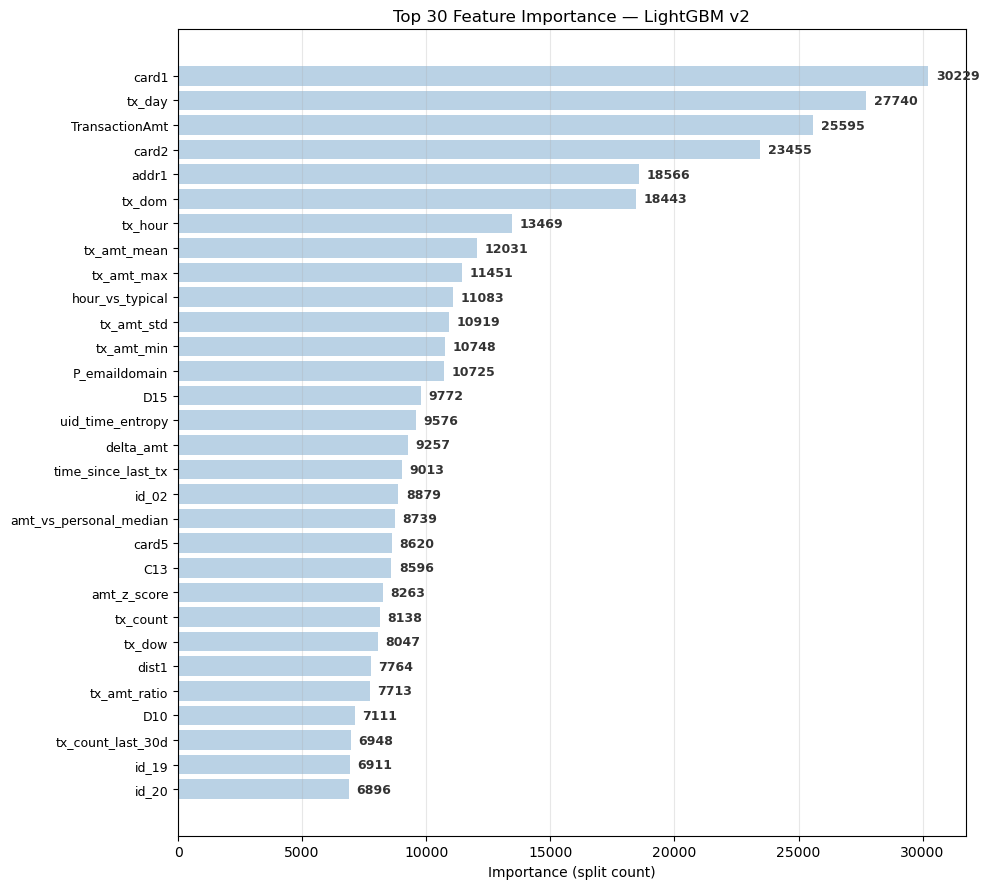

In [ ]:
if 'y_pred_lgbm' not in globals():
    print('⏭️  Skipped — LightGBM was not trained')
else:
    lgbm_roc = roc_auc_score(y_val, y_pred_lgbm)
    lgbm_pr  = average_precision_score(y_val, y_pred_lgbm)

    print(f"{'='*52}")
    print(f"  {'Model':<18} {'ROC AUC':>8}  {'PR AUC':>8}")
    print(f"{'='*52}")
    print(f"  {'v0 baseline':<18} {V0_ROC_AUC:>8.4f}  {V0_PR_AUC:>8.4f}")
    print(f"  {'v2 LightGBM':<18} {lgbm_roc:>8.4f}  {lgbm_pr:>8.4f}"
          f"   Δ ROC={lgbm_roc - V0_ROC_AUC:+.4f}  Δ PR={lgbm_pr - V0_PR_AUC:+.4f}")
    print(f"{'='*52}")

    plot_roc_pr(y_val, y_pred_lgbm, model_name='v2 LightGBM')

    imp_df = plot_feature_importance(
        model_lgbm,
        feature_names=X_val_lgbm.columns.tolist(),
        top_n=30,
        model_name='LightGBM v2',
    )

# Step 5: XGBoost

## Step 5.1: Train XGBoost

In [ ]:
if RETRAIN_XGB or not MODEL_FILES['xgb'].exists():
    model_xgb, y_pred_xgb = train_xgb_model(
        X_train_lgbm, y_train,
        X_val_lgbm,   y_val,
        models_dir  = MODELS_DIR,
        params_path = str(PARAM_FILES['xgb']),
    )
else:
    import xgboost as xgb_lib
    with open(MODEL_FILES['xgb'], 'rb') as f:
        model_xgb = pickle.load(f)
    dval       = xgb_lib.DMatrix(X_val_lgbm)
    y_pred_xgb = model_xgb.predict(
        dval, iteration_range=(0, model_xgb.best_iteration + 1)
    ).astype('float32')
    print(f'✅  Loaded model_xgb ← {MODEL_FILES["xgb"]}')

✅  Loaded model_xgb ← C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_xgb.pkl


## Step 5.2: Evaluate XGBoost

  Model               ROC AUC    PR AUC
  v0 baseline          0.9196    0.5804
  v2 XGBoost           0.9226    0.5641   Δ ROC=+0.0030  Δ PR=-0.0163


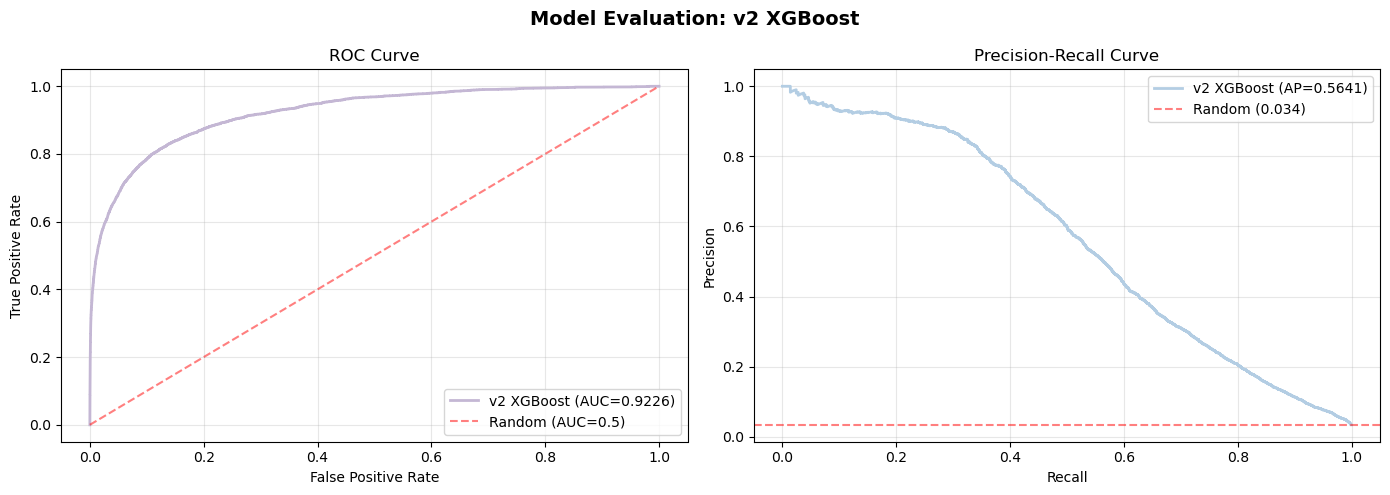

>> Top 30 features by importance:
     1. V258                            importance: 7357.26220703125
     2. V70                             importance: 4179.59619140625
     3. V218                            importance: 3269.943359375
     4. V257                            importance: 3070.485107421875
     5. V294                            importance: 2396.721435546875
     6. V91                             importance: 2389.8525390625
     7. V201                            importance: 1846.0113525390625
     8. V264                            importance: 1386.72314453125
     9. V219                            importance: 1292.5810546875
    10. V295                            importance: 1199.0206298828125
    11. V199                            importance: 957.4242553710938
    12. V325                            importance: 870.3464965820312
    13. C8                              importance: 853.5284423828125
    14. V322                            importance: 848.59844970

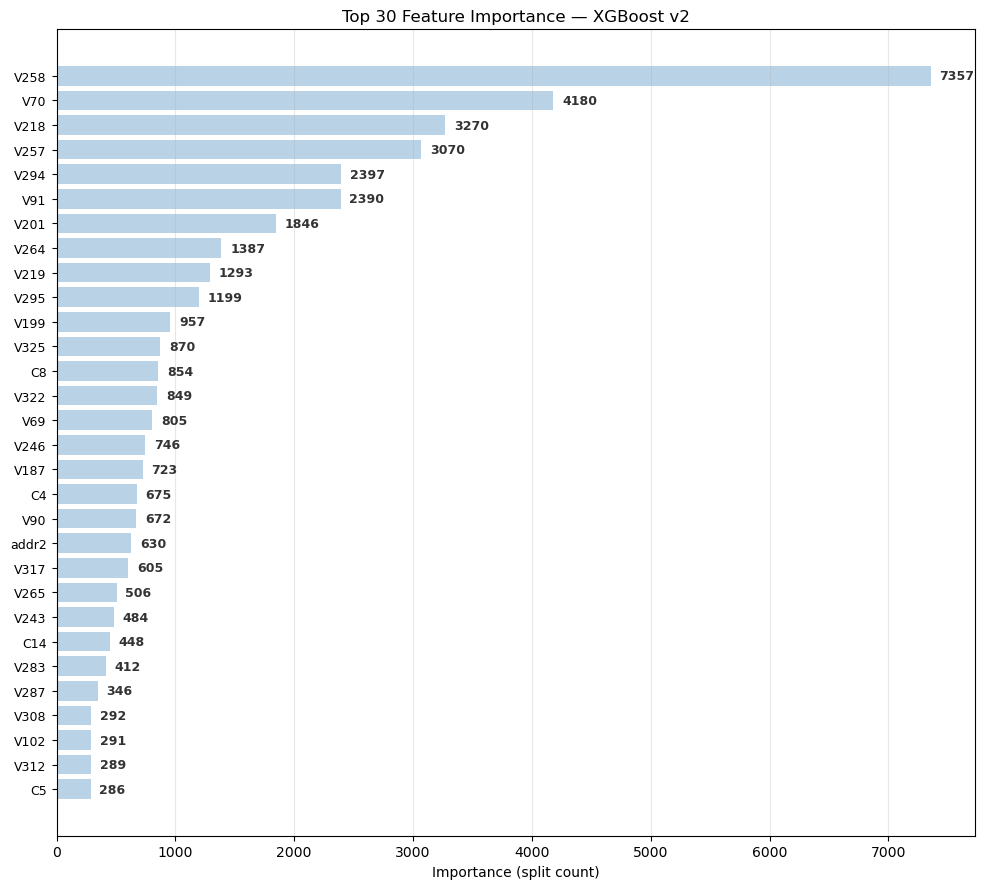

In [ ]:
if 'y_pred_xgb' not in globals():
    print('⏭️  Skipped — XGBoost was not trained')
else:
    xgb_roc = roc_auc_score(y_val, y_pred_xgb)
    xgb_pr  = average_precision_score(y_val, y_pred_xgb)

    print(f"{'='*52}")
    print(f"  {'Model':<18} {'ROC AUC':>8}  {'PR AUC':>8}")
    print(f"{'='*52}")
    print(f"  {'v0 baseline':<18} {V0_ROC_AUC:>8.4f}  {V0_PR_AUC:>8.4f}")
    print(f"  {'v2 XGBoost':<18} {xgb_roc:>8.4f}  {xgb_pr:>8.4f}"
          f"   Δ ROC={xgb_roc - V0_ROC_AUC:+.4f}  Δ PR={xgb_pr - V0_PR_AUC:+.4f}")
    print(f"{'='*52}")

    plot_roc_pr(y_val, y_pred_xgb, model_name='v2 XGBoost')

    imp_df_xgb = plot_feature_importance(
        model_xgb,
        feature_names=X_val_lgbm.columns.tolist(),
        top_n=30,
        model_name='XGBoost v2',
    )

# Step 6: Ensemble — Weighted Average

```
weight_i   = AUC_i / sum(AUC_j for all j)
y_ensemble = w_lgbm * y_lgbm + w_xgb * y_xgb
```

Runs automatically when both LightGBM and XGBoost are trained.


## Step 6.1: Weighted Average


In [ ]:
_preds_needed = ['y_pred_lgbm', 'y_pred_xgb']
_all_trained  = all(v in globals() for v in _preds_needed)

if not _all_trained:
    _missing = [v for v in _preds_needed if v not in globals()]
    print(f'⏭️  Ensemble skipped — missing predictions: {_missing}')
else:
    from train_ensemble import compute_weights, weighted_average, evaluate_ensemble

    scores = {
        'lgbm': roc_auc_score(y_val, y_pred_lgbm),
        'xgb' : roc_auc_score(y_val, y_pred_xgb),
    }
    weights         = compute_weights(scores)
    y_pred_ensemble = weighted_average(
        {'lgbm': y_pred_lgbm, 'xgb': y_pred_xgb},
        weights,
    )
    print('✅  Ensemble (LightGBM + XGBoost) computed')
    print(f'   Weights: {", ".join(f"{k}={v:.4f}" for k, v in weights.items())}')


✅  Ensemble (LightGBM + XGBoost) computed
   Weights: lgbm=0.5012, xgb=0.4988


## Step 6.2: Evaluate Ensemble


ENSEMBLE EVALUATION

   Weights:
     lgbm      : 0.5012
     xgb       : 0.4988

   Results (sorted by ROC AUC):

────────────────────────────────────────────────────────────
   Model           ROC AUC     PR AUC     ΔROC AUC    ΔPR AUC
────────────────────────────────────────────────────────────
   lgbm             0.9272     0.6039      +0.0000    +0.0000
   ensemble         0.9264     0.5907      -0.0008    -0.0132 ◄
   xgb              0.9226     0.5641      -0.0046    -0.0398
────────────────────────────────────────────────────────────

   Prediction correlations (lower = more diverse = better ensemble):
     lgbm vs xgb: 0.8707  (good)


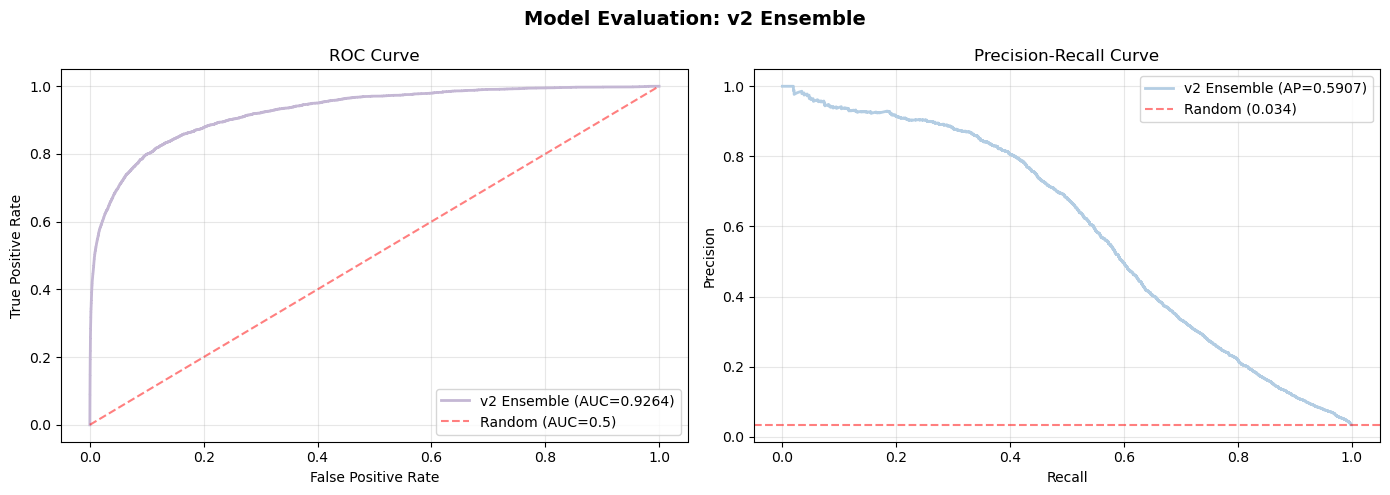

In [ ]:
if 'y_pred_ensemble' not in globals():
    print('⏭️  Skipped — Ensemble was not computed')
else:
    predictions_all = {
        'lgbm':     y_pred_lgbm,
        'xgb':      y_pred_xgb,
        'ensemble': y_pred_ensemble,
    }
    results_df = evaluate_ensemble(y_val, predictions_all, weights=weights)
    plot_roc_pr(y_val, y_pred_ensemble, model_name='v2 Ensemble')

# Step 8: Full Evaluation — All Models vs V0 Baseline

Summary table comparing all trained models against V0 baseline.

In [ ]:
_trained_preds = {
    'v2 LightGBM': 'y_pred_lgbm',
    'v2 XGBoost':  'y_pred_xgb',
    'v2 Ensemble': 'y_pred_ensemble',
}

rows = [{'Model': 'v0 baseline', 'ROC AUC': V0_ROC_AUC, 'PR AUC': V0_PR_AUC}]
for name, var in _trained_preds.items():
    if var in globals():
        y_pred = eval(var)
        rows.append({
            'Model':   name,
            'ROC AUC': roc_auc_score(y_val, y_pred),
            'PR AUC':  average_precision_score(y_val, y_pred),
        })

comparison = pd.DataFrame(rows)
comparison['Δ ROC AUC'] = comparison['ROC AUC'].apply(lambda x: f'{x - V0_ROC_AUC:+.4f}')
comparison['Δ PR AUC']  = comparison['PR AUC'].apply(lambda x: f'{x - V0_PR_AUC:+.4f}')
comparison.loc[comparison['Model'] == 'v0 baseline', ['Δ ROC AUC', 'Δ PR AUC']] = '—'

print(comparison.to_string(index=False))


      Model  ROC AUC   PR AUC Δ ROC AUC Δ PR AUC
v0 baseline 0.919600 0.580400         —        —
v2 LightGBM 0.927187 0.603910   +0.0076  +0.0235
 v2 XGBoost 0.922619 0.564101   +0.0030  -0.0163
v2 Ensemble 0.926418 0.590735   +0.0068  +0.0103
